# Proyecto de Estadística Bayesiana: Eficiencia Individual en el Baloncesto

Este notebook implementa un **Modelo de Regresión Logística Bayesiana** para estimar la contribución individual de cada jugador al éxito de una jugada. 

**Objetivo:** Predecir la probabilidad de éxito (`Exit`) basándonos en los jugadores presentes en pista.

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Configuración para gráficos
az.style.use('arviz-darkgrid')

## 1. Carga y Preparación de Datos

Basándonos en tu archivo `Data_AllSeason.csv`, vamos a transformar los quintetos en una matriz binaria (One-Hot Encoding manual).

In [2]:
# 1. Cargar el dataset
# Nota: Asegúrate de que el archivo CSV esté en la misma carpeta que este notebook
try:
    df = pd.read_csv('data/Data_AllSeason.csv')

    headers = ['Jugada', 'Base', 'Escorta', 'Aler', 'Alerpivot', 'Pivot', 'Diferencial', 'TipusJugada', 'Exit', 
                'Punts', 'Quart', 'Clutch', 'Rival', 'Terreny', 'Competition']
    df.columns = headers
except FileNotFoundError:
    print("Error: No se encontró 'Data_AllSeason.csv'. Por favor, cárgalo.")

# 2. Definir lista de todos los jugadores únicos
player_cols = ['Base', 'Escorta', 'Aler', 'Alerpivot', 'Pivot']
all_players = sorted(list(set(df[player_cols].values.flatten())))

print(f"Total de jugadores detectados: {len(all_players)}")

# 3. Crear matriz X (Variables independientes)
# Cada columna será un jugador (1 si está en pista, 0 si no)
X_data = pd.DataFrame(0, index=df.index, columns=all_players)

for col in player_cols:
    for idx, player in df[col].items():
        X_data.loc[idx, player] = 1

# 4. Definir variable objetivo y
y_data = df['Exit'].values

X_data.head()

Total de jugadores detectados: 19


,Abrines,Bonilla,Caicedo,Calathes,Davies,Exum,Hayes-Davis,Higgins,Jokubaitis,Kuric,Laprovittola,Martinez,Mirotic,Nnaji,Oriola,Sanli,Smits,Ubal,Villar
0,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0
3,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,1,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0


## 2. Construcción del Modelo Bayesiano

Utilizaremos una regresión logística donde:
- **Prior**: Distribuciones Normales para los coeficientes de cada jugador.
- **Likelihood**: Distribución de Bernoulli para la variable binaria `Exit`.

In [3]:
with pm.Model() as basketball_model:
    # --- Priors ---
    # Intercepto (probabilidad base de éxito del equipo)
    alpha = pm.Normal('alpha', mu=0, sigma=1)
    
    # Coeficientes para cada jugador (beta)
    # Usamos una Normal centrada en 0. 
    # Si beta > 0, el jugador aumenta la prob. de éxito.
    beta = pm.Normal('beta', mu=0, sigma=1, shape=len(all_players))
    
    # --- Combinación lineal ---
    # logit(p) = alpha + beta1*X1 + beta2*X2 + ...
    mu = alpha + pm.math.dot(X_data.values, beta)
    
    # --- Likelihood ---
    # Transformamos mu a probabilidad con la función sigmoide (invlogit)
    p = pm.math.invlogit(mu)
    
    # Observaciones
    out = pm.Bernoulli('success', p=p, observed=y_data)

## 3. Inferencia (MCMC Sampling)

Ejecutamos el algoritmo de Monte Carlo para obtener las muestras de la distribución *posterior*.

In [4]:
with basketball_model:
    # Realizamos el muestreo (esto puede tardar un par de minutos)
    trace = pm.sample(1000, tune=1000, chains=2, target_accept=0.9)
    
print("Muestreo completado.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 94 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Muestreo completado.


## 4. Análisis de Resultados

Visualizamos qué jugadores tienen un impacto positivo o negativo real.

In [5]:
# Resumen estadístico de los coeficientes de los jugadores
summary = az.summary(trace, var_names=['beta'])
summary.index = all_players
summary = summary.sort_values(by='mean', ascending=False)

summary.head(10) # Los 10 jugadores con mayor impacto positivo medio

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Davies,0.360,0.189,0.001,0.707,0.013,0.007,217.0,442.0,1.0
Sanli,0.349,0.191,0.018,0.733,0.013,0.006,228.0,438.0,1.0
Mirotic,0.273,0.180,-0.065,0.611,0.012,0.006,243.0,475.0,1.0
Abrines,0.230,0.192,-0.112,0.590,0.012,0.006,242.0,418.0,1.0
Oriola,0.219,0.197,-0.141,0.606,0.012,0.006,285.0,639.0,1.0
Smits,0.141,0.180,-0.195,0.495,0.012,0.006,217.0,463.0,1.0
Martinez,0.135,0.183,-0.213,0.453,0.013,0.007,206.0,396.0,1.0
Kuric,0.038,0.175,-0.298,0.353,0.012,0.006,213.0,396.0,1.0
Laprovittola,0.025,0.177,-0.311,0.347,0.012,0.007,235.0,392.0,1.0
Hayes-Davis,-0.004,0.172,-0.315,0.334,0.012,0.006,220.0,408.0,1.0


<Figure size 1000x1200 with 0 Axes>

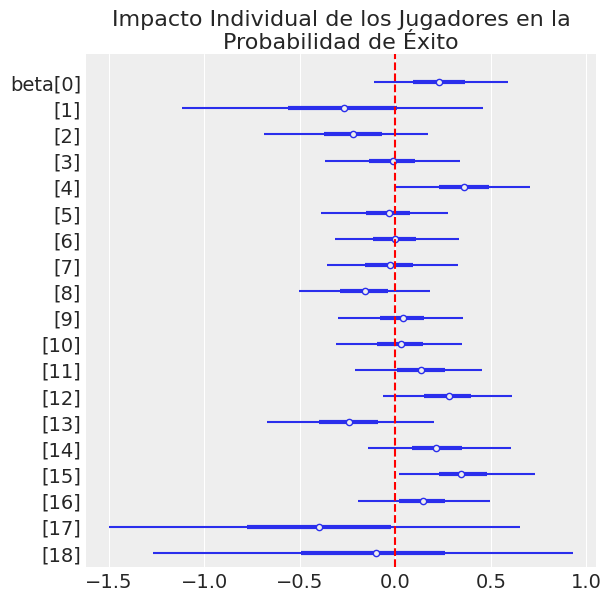

In [6]:
# Gráfico de Bosque (Forest Plot)
# Permite ver los Intervalos de Credibilidad del 94%
plt.figure(figsize=(10, 12))
az.plot_forest(trace, var_names=['beta'], combined=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Impacto Individual de los Jugadores en la Probabilidad de Éxito')
plt.show()

## 5. Interpretación de la Posterior

Una de las ventajas de Bayes es que podemos responder preguntas de probabilidad directa. 

**Ejemplo:** ¿Cuál es la probabilidad de que Mirotic aporte más que Davies?

Probabilidad de que el impacto de Mirotic sea mayor que el de Davies: 25.95%


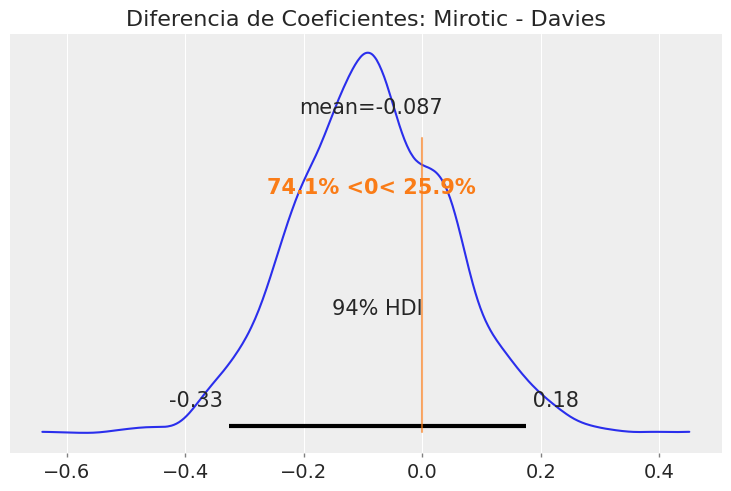

In [7]:
# Extraemos las muestras de la posterior para dos jugadores
try:
    # Buscamos los índices de los jugadores en nuestra lista
    idx_mirotic = all_players.index('Mirotic')
    idx_davies = all_players.index('Davies')

    mirotic_post = trace.posterior['beta'].values[:, :, idx_mirotic].flatten()
    davies_post = trace.posterior['beta'].values[:, :, idx_davies].flatten()

    prob_better = np.mean(mirotic_post > davies_post)
    print(f"Probabilidad de que el impacto de Mirotic sea mayor que el de Davies: {prob_better:.2%}")
    
    # Visualización de la comparación
    az.plot_posterior(mirotic_post - davies_post, ref_val=0)
    plt.title('Diferencia de Coeficientes: Mirotic - Davies')
except ValueError:
    print("Jugadores no encontrados en la lista. Verifica los nombres exactos.")